# Spotify Data Analysis Using Python

## Introduction

This project analyzes Spotify songs to identify trends in song popularity, artist dominance, release patterns and audio features.

## Project Objective

The objective of this project is to analyze Spotify song data to identify patterns in music popularity, artist performance, release trends and audio features.

The project aims to answer the following questions:

- Which songs are the most streamed?
- Which artists dominate Spotify?
- How have song releases changed over time?
- Which audio features are common in popular songs?
- What relationships exist between different song characteristics?

## Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [8]:
df = pd.read_csv("spotify dataset.csv", encoding="latin1")

df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## Data Cleaning

In [9]:
print("\nFirst 5 rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)


First 5 rows
                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year  released_month  released_day  in_spotify_playlists  \
0           2023               7            14                   553   
1           2023               3            23                  1474   
2           2023               6            30                  1397   
3           2019               8            23                  7858   
4           2023               5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  ...  bpm key   mode  \
0                147  141381703 

In [10]:
print(df.isnull().sum())

track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64


In [11]:
print(df.duplicated().sum())

0


Clean streams column

In [12]:


df["streams"] = pd.to_numeric(df["streams"], errors="coerce")

# Remove rows with empty streams

df = df.dropna(subset=["streams"])

print(df["streams"].dtype)

float64


In [26]:
df.describe()


,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,9.520000e+02,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000
mean,1.556723,2018.288866,6.038866,13.944328,5202.565126,12.022059,5.141374e+08,67.866597,51.963235,2.669118,122.553571,66.984244,51.406513,64.274160,27.078782,1.582983,18.214286,10.138655
std,0.893331,11.011397,3.564571,9.197223,7901.400683,19.582405,5.668569e+08,86.470591,50.628850,6.038152,28.069601,14.631282,23.480526,16.558517,26.001599,8.414064,13.718374,9.915399
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,65.000000,23.000000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,874.500000,0.000000,1.416362e+08,13.000000,7.000000,0.000000,99.750000,57.000000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2216.500000,3.000000,2.905309e+08,34.000000,38.500000,0.000000,121.000000,69.000000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5573.750000,16.000000,6.738690e+08,88.000000,87.000000,2.000000,140.250000,78.000000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,58.000000,206.000000,96.000000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


Save cleaned data

In [14]:
df.to_csv(
    "spotify_cleaned.csv",
    index=False
)

print("Cleaned file saved")

Cleaned file saved


## Exploratory Data Analysis

Top 10 streamed songs

In [28]:
top10 = df.sort_values(
    by="streams",
    ascending=False
).head(10)

top10[["track_name","artist(s)_name","streams"]]

,track_name,artist(s)_name,streams
55,Blinding Lights,The Weeknd,3.703895e+09
179,Shape of You,Ed Sheeran,3.562544e+09
86,Someone You Loved,Lewis Capaldi,2.887242e+09
620,Dance Monkey,Tones and I,2.864792e+09
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2.808097e+09
162,One Dance,"Drake, WizKid, Kyla",2.713922e+09
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2.665344e+09
140,Believer,Imagine Dragons,2.594040e+09
725,Closer,"The Chainsmokers, Halsey",2.591224e+09
48,Starboy,"The Weeknd, Daft Punk",2.565530e+09


Creating Graph

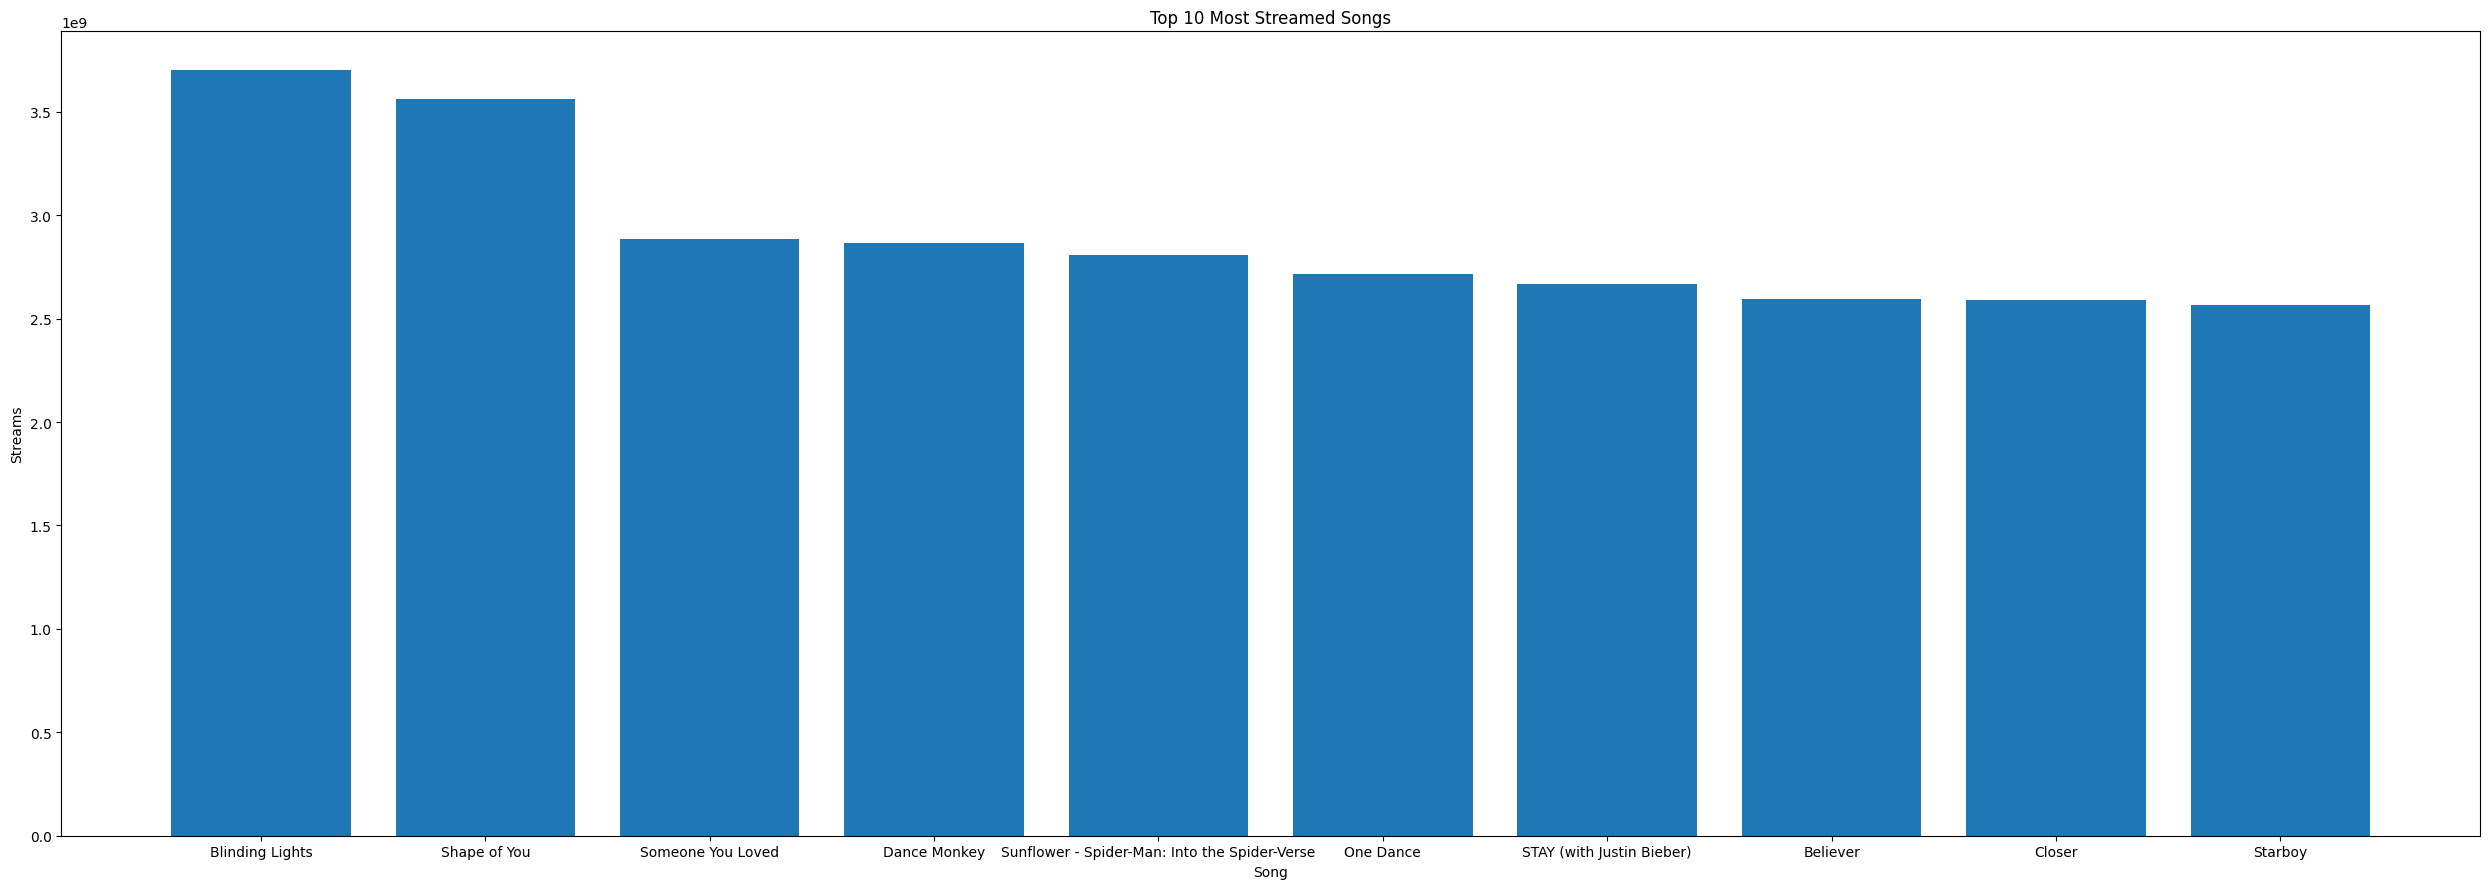

In [16]:
plt.figure(figsize=(25, 9))

plt.bar(
    top10["track_name"],
    top10["streams"]
)

plt.xticks(rotation=360)

plt.title("Top 10 Most Streamed Songs")

plt.xlabel("Song")

plt.ylabel("Streams")

plt.tight_layout()

plt.savefig("top10_songs.png")

plt.show()

Top 10 artists

In [30]:
top_artists = (
    df.groupby("artist(s)_name")["streams"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_artists)

artist(s)_name
The Weeknd         1.418555e+10
Taylor Swift       1.405366e+10
Ed Sheeran         1.390895e+10
Harry Styles       1.160865e+10
Bad Bunny          9.997800e+09
Olivia Rodrigo     7.442149e+09
Eminem             6.183806e+09
Bruno Mars         5.846921e+09
Arctic Monkeys     5.569807e+09
Imagine Dragons    5.272485e+09
Name: streams, dtype: float64


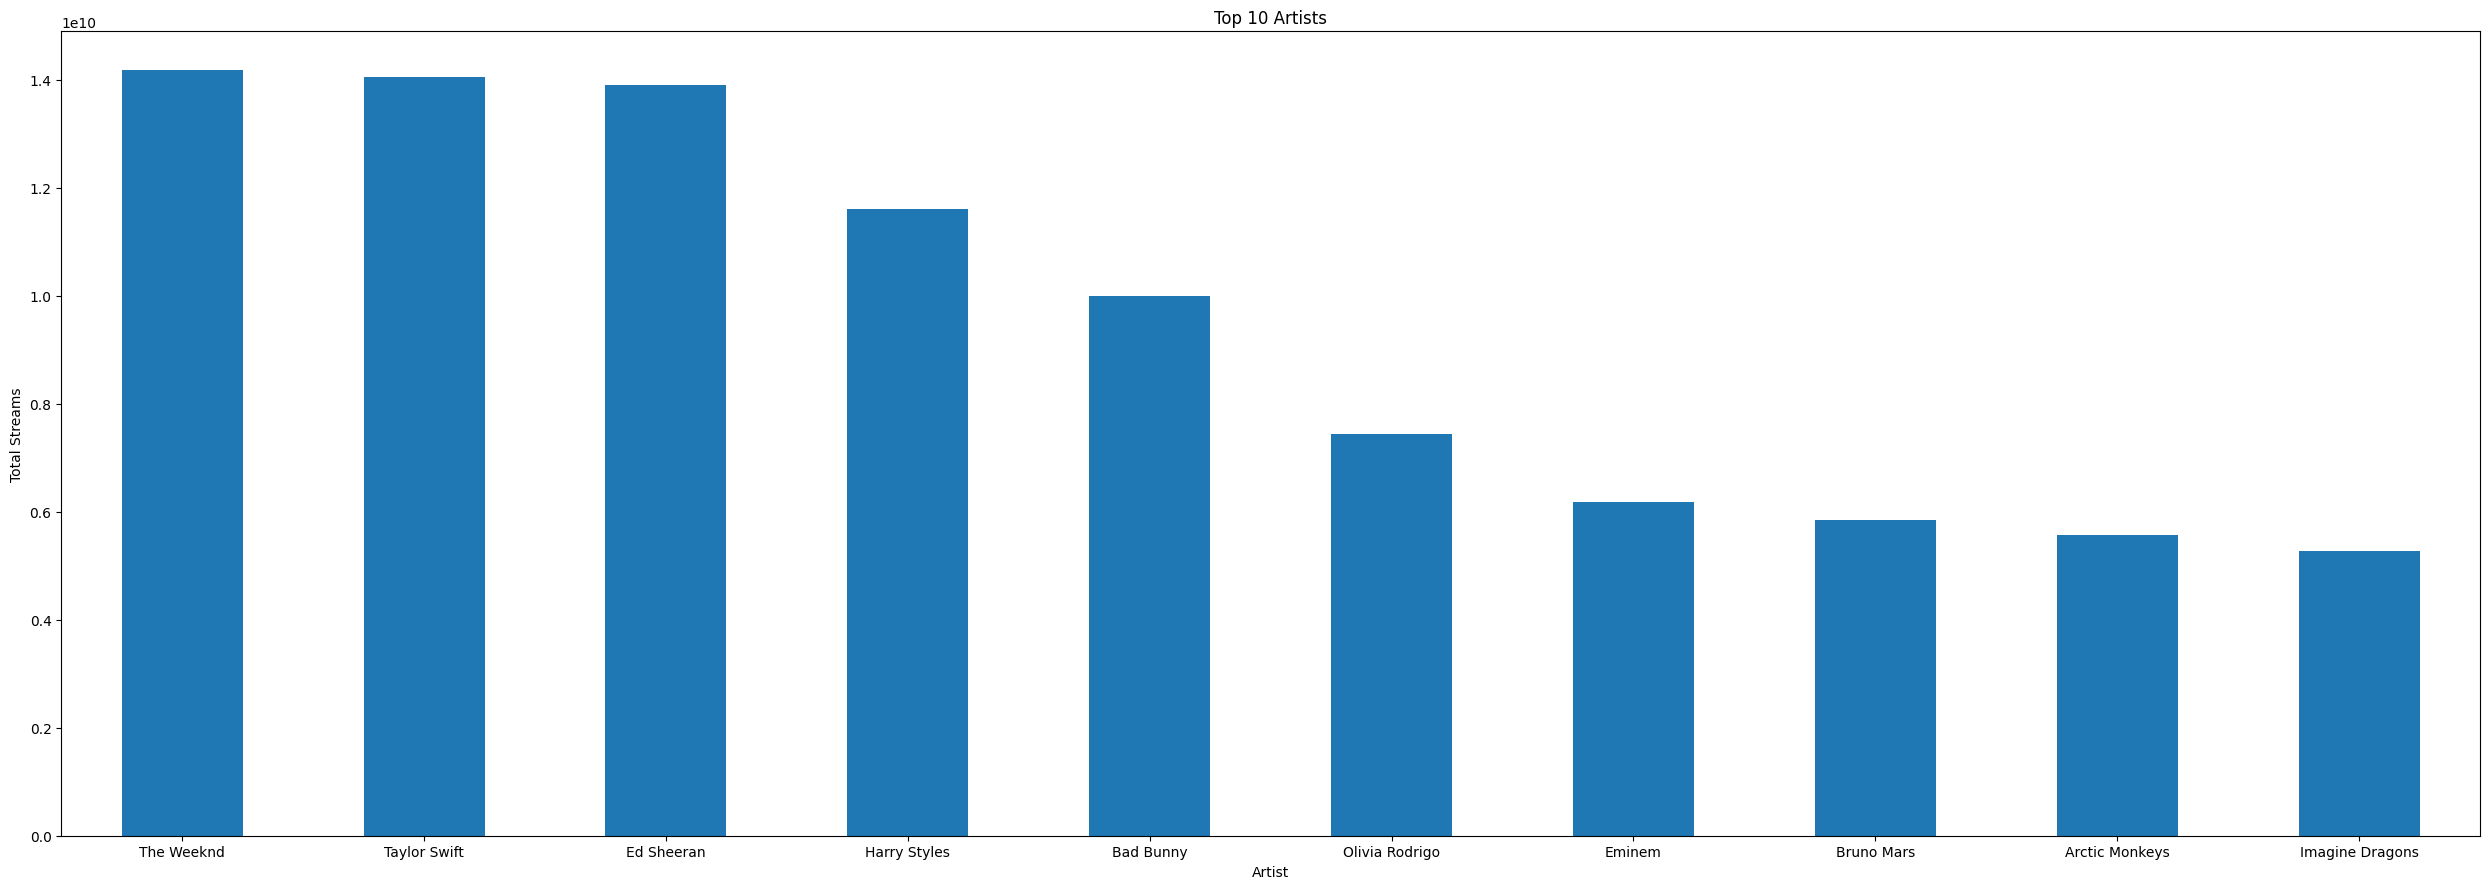

In [18]:
plt.figure(figsize=(25, 9 ))

top_artists.plot(kind="bar")

plt.xticks(rotation=360)

plt.title("Top 10 Artists")

plt.xlabel("Artist")

plt.ylabel("Total Streams")

plt.tight_layout()

plt.savefig("top_artists.png")

plt.show()

Average audio features

In [19]:
features = [
    "danceability_%",
    "energy_%",
    "valence_%",
    "acousticness_%",
    "speechiness_%"
]

df[features].mean()

danceability_%    66.984244
energy_%          64.274160
valence_%         51.406513
acousticness_%    27.078782
speechiness_%     10.138655
dtype: float64

Songs released each year

In [33]:
songs_per_year = (
    df["released_year"]
    .value_counts()
    .sort_index()
)

songs_per_year.to_frame(name="Number of Songs")

,Number of Songs
released_year,
1930,1
1942,1
1946,1
1950,1
1952,1
1957,2
1958,3
1959,2
1963,3


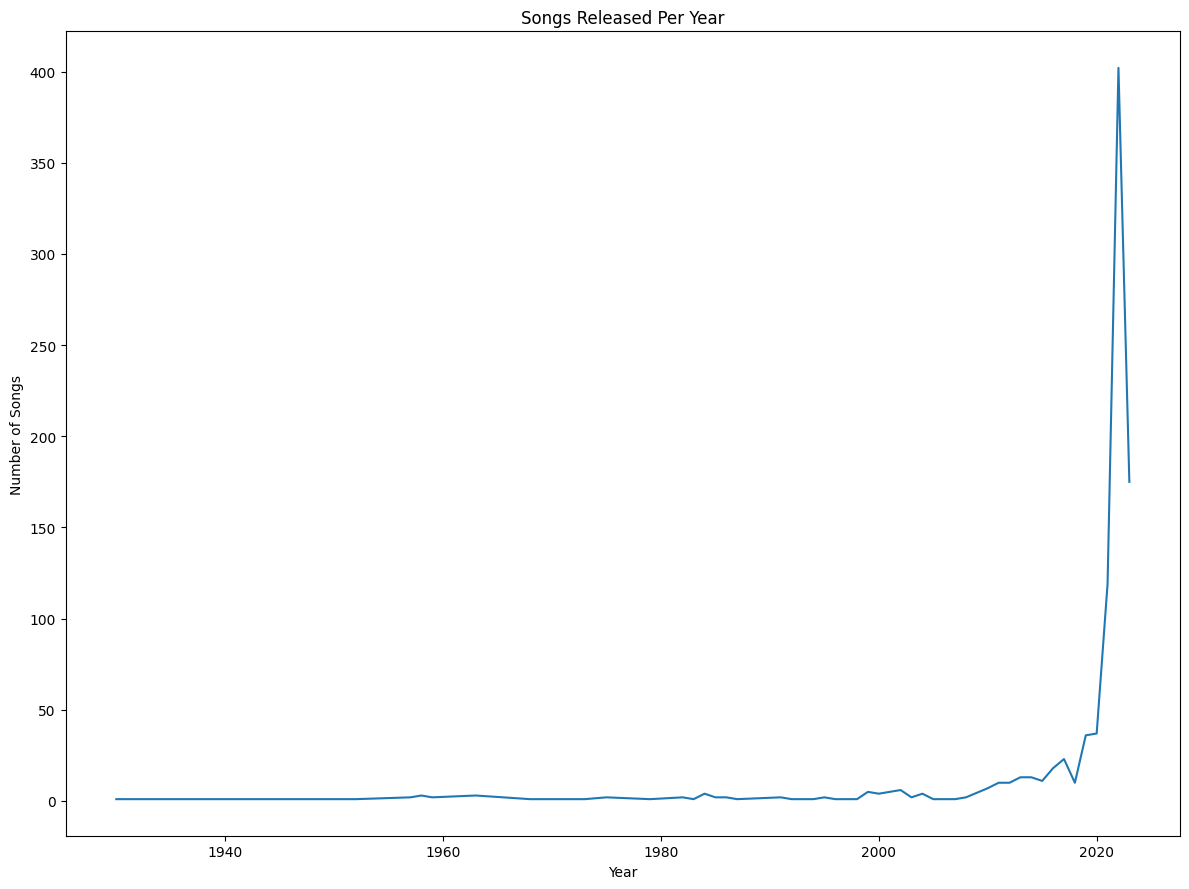

In [21]:
plt.figure(figsize=(12, 9))

songs_per_year.plot()

plt.xticks(rotation=360)

plt.title("Songs Released Per Year")

plt.xlabel("Year")

plt.ylabel("Number of Songs")

plt.tight_layout()

plt.savefig("songs_per_year.png")

plt.show()

Correlation heatmap

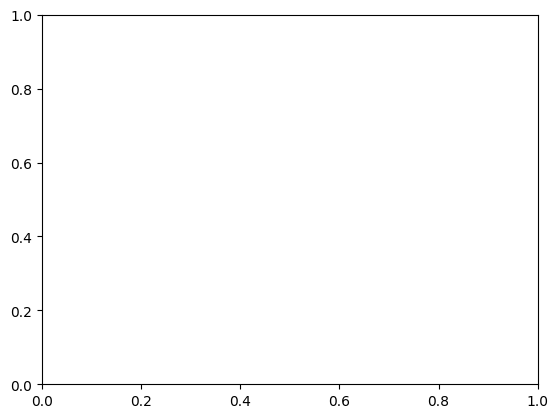

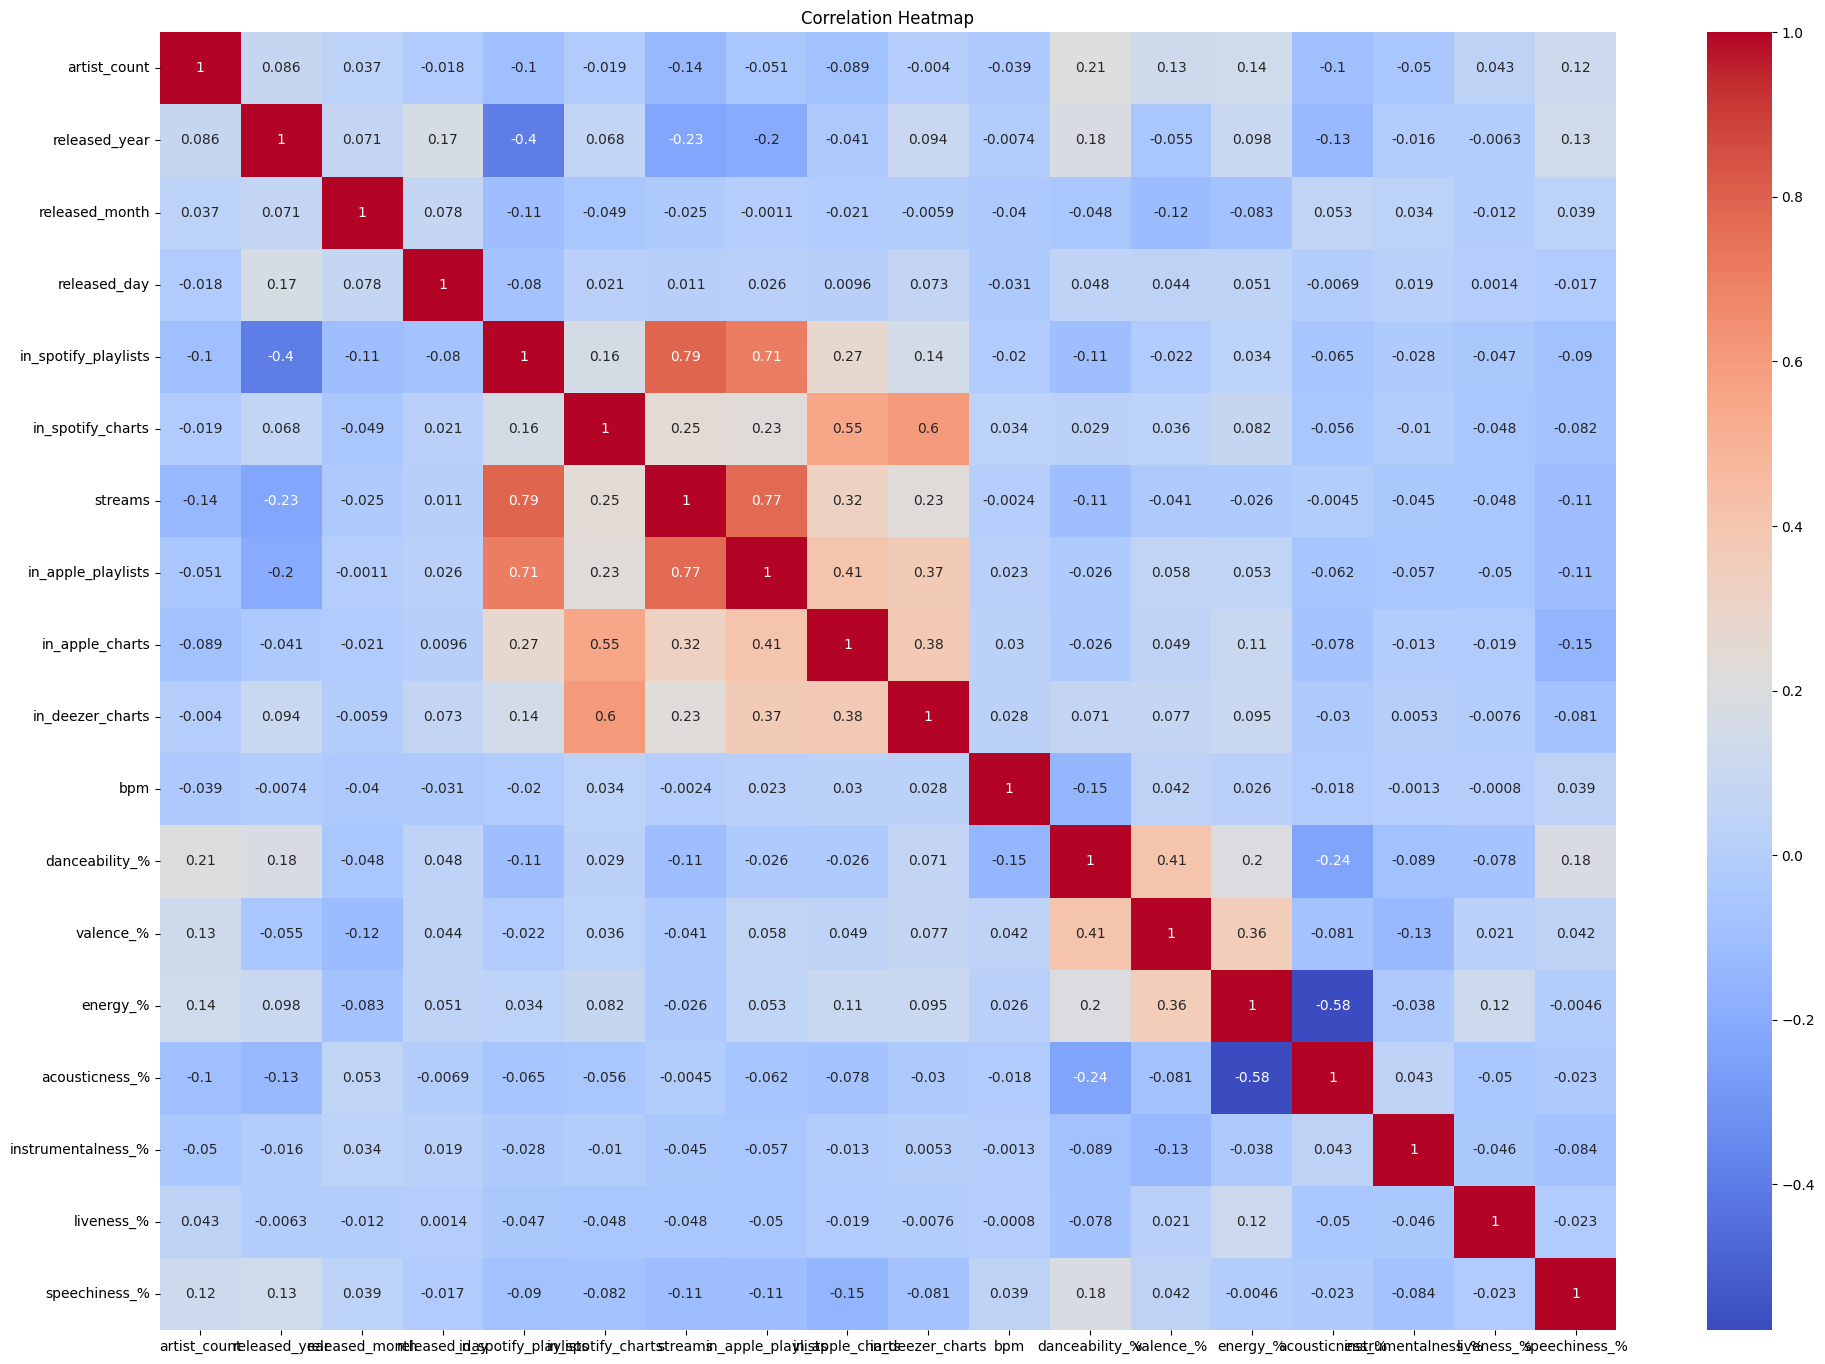

In [23]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.xticks(rotation=360)

plt.figure(figsize=(20,15))



sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.xticks(rotation=360)

plt.savefig("heatmap.png")

plt.show()

In [24]:
import os

print(os.getcwd())
print(os.listdir())


c:\Users\Riya Dubey\spotifyanalysis.ipynb
['heatmap.png', 'output.png', 'songs_per_year.png', 'spotify dataset.csv', 'spotifyanalysis.ipynb', 'spotify_cleaned.csv', 'top10_songs.png', 'top_artists.png']


In [25]:
import os

for file in os.listdir():
    print(file)

heatmap.png
output.png
songs_per_year.png
spotify dataset.csv
spotifyanalysis.ipynb
spotify_cleaned.csv
top10_songs.png
top_artists.png


## Relationship Between Danceability and Streams

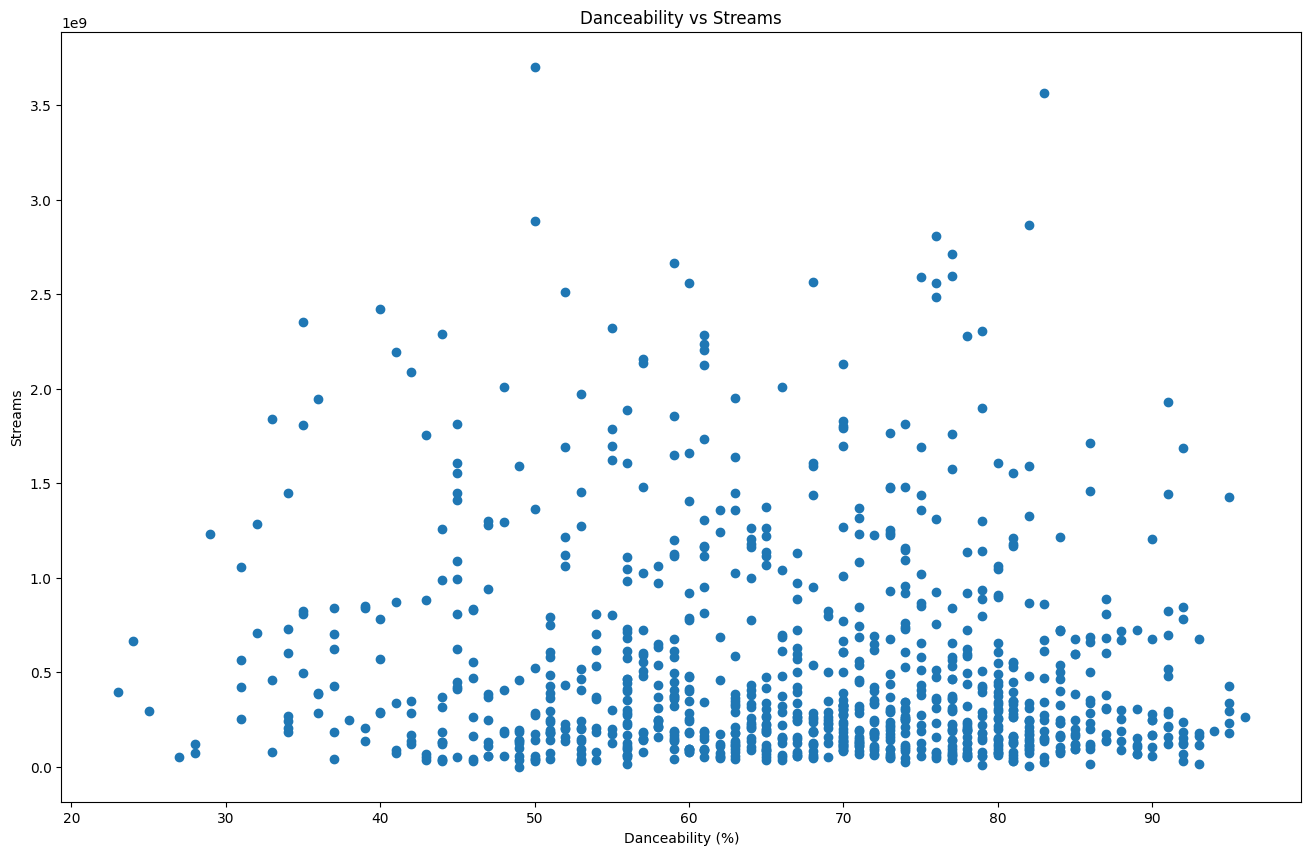

In [36]:
plt.figure(figsize=(16,10))

plt.scatter(
    df["danceability_%"],
    df["streams"]
)

plt.title("Danceability vs Streams")

plt.xlabel("Danceability (%)")

plt.ylabel("Streams")

plt.show()

## Key Insights

1. A small number of songs dominate Spotify, accumulating billions of streams compared to the majority of tracks.

2. A few artists contribute a significant portion of total streams, showing a high concentration of popularity among top performers.

3. The number of songs released has increased over time, especially in recent years.

4. Popular songs commonly exhibit higher danceability and energy levels.

5. Audio features such as energy, valence and danceability show relationships that influence listening patterns.

6. Correlation analysis revealed that some song characteristics are interconnected rather than independent.

7. Data visualization made it easier to identify trends, patterns and outliers within the dataset.

## Conclusion

This project analyzed Spotify song data using Python, Pandas, Matplotlib and Seaborn.

The dataset was cleaned, explored and visualized to identify trends in song popularity, artist performance, release patterns and audio characteristics.

The analysis demonstrated how data visualization can transform raw music data into meaningful insights and help understand listener preferences and music trends.